# Step 4 — Model Training

This notebook trains the UNet model on the preprocessed nuclei segmentation dataset.
The preprocessed data was produced in Step 2 (Preprocessing Pipeline) and stored
as `.npz` archives on Google Drive.

**What this notebook does:**
- Loads the preprocessed train and validation splits
- Trains UNet for 50 epochs using combined BCE + Dice loss
- Saves the best model checkpoint based on validation Dice score
- Produces training curves and visual predictions

---

| | |
|:---|:---|
| **Dataset** | 2018 Kaggle Data Science Bowl — Nuclei Segmentation |
| **Model** | UNet — Ronneberger et al., MICCAI 2015 |
| **Loss** | BCE + Dice |
| **Best Dice** | 0.9180 (epoch 50) |

## 1. Environment Setup

Mount Google Drive to access the preprocessed data, clone the project repository, and install all required libraries.

In [1]:
# Mount Google Drive
# All preprocessed .npz archives are stored on Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Clone the latest version of the project from GitHub
# Always re-clone to ensure we train with the most recent code
!git clone https://github.com/Norhankamal/Medical-Image-Segmentation-with-UNet-Variants.git

Cloning into 'Medical-Image-Segmentation-with-UNet-Variants'...
remote: Enumerating objects: 261, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 261 (delta 48), reused 29 (delta 25), pack-reused 177 (from 1)
Receiving objects: 100% (261/261), 3.63 MiB | 10.11 MiB/s, done.
Resolving deltas: 100% (80/80), done.


In [3]:
# Install required libraries
!pip install torch torchvision pyyaml opencv-python matplotlib tqdm

## 2. Verify Preprocessed Data

Confirm the three `.npz` archives produced by Notebook 02 are accessible on Drive before starting training. If any file is missing, re-run Notebook 02 first.

In [4]:
# Verify preprocessed .npz files are accessible on Drive
import os

base = "/content/drive/MyDrive/Medical_Segmentation_Data/preprocessed"
print("Preprocessed files found:")
for f in sorted(os.listdir(base)):
    size = os.path.getsize(f"{base}/{f}") / (1024**2)
    print(f"  {f:<35} {size:.1f} MB")

Preprocessed files found:
  test_preprocessed.npz               10.7 MB
  train_preprocessed.npz              51.0 MB
  val_preprocessed.npz                11.1 MB


In [5]:
# Confirm GPU is available — training on CPU would take several hours
# If this prints 'cpu', go to Runtime > Change runtime type > T4 GPU
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 3. Training

Run the full training pipeline. The model trains for 50 epochs, logging Train Loss, Val Loss, Dice, and IoU at each epoch. The best checkpoint is saved automatically to `checkpoints/best_model.pth` based on validation Dice score.

In [ ]:
with open('/content/Medical-Image-Segmentation-with-UNet-Variants/src/evaluate.py', 'r') as f:
    content = f.read()

# Replace non-breaking spaces with regular spaces
content = content.replace('\u00a0', ' ')

with open('/content/Medical-Image-Segmentation-with-UNet-Variants/src/evaluate.py', 'w') as f:
    f.write(content)

print("Fixed!")

In [7]:
# Run the full training pipeline
# Logs epoch-by-epoch: Train Loss | Val Loss | Dice | IoU
# Best model saved to checkpoints/best_model.pth
!cd /content/Medical-Image-Segmentation-with-UNet-Variants && python -m src.train

Device: cuda

Training UNet for 50 epochs

 Epoch   Train Loss   Val Loss     Dice      IoU
--------------------------------------------------
     1       0.9477     0.9033   0.6904   0.5306
         -> best model saved (Dice 0.6904)
     2       0.6896     0.6422   0.8551   0.7481
         -> best model saved (Dice 0.8551)
     3       0.6143     0.5574   0.8818   0.7905
         -> best model saved (Dice 0.8818)
     4       0.5651     0.5491   0.8782   0.7857
     5       0.5012     0.5290   0.8794   0.7856
     6       0.4498     0.3761   0.8929   0.8082
         -> best model saved (Dice 0.8929)
     7       0.4227     0.4090   0.8936   0.8093
         -> best model saved (Dice 0.8936)
     8       0.3888     0.3282   0.9077   0.8318
         -> best model saved (Dice 0.9077)
     9       0.3569     0.3383   0.9032   0.8249
    10       0.3431     0.3392   0.9073   0.8314
    11       0.3184     0.3352   0.9039   0.8257
    12       0.3045     0.2687   0.9095   0.8348
         ->

## 4. Results

Training curves, prediction visualizations, and final metrics are saved automatically to `reports/figures/` at the end of training.

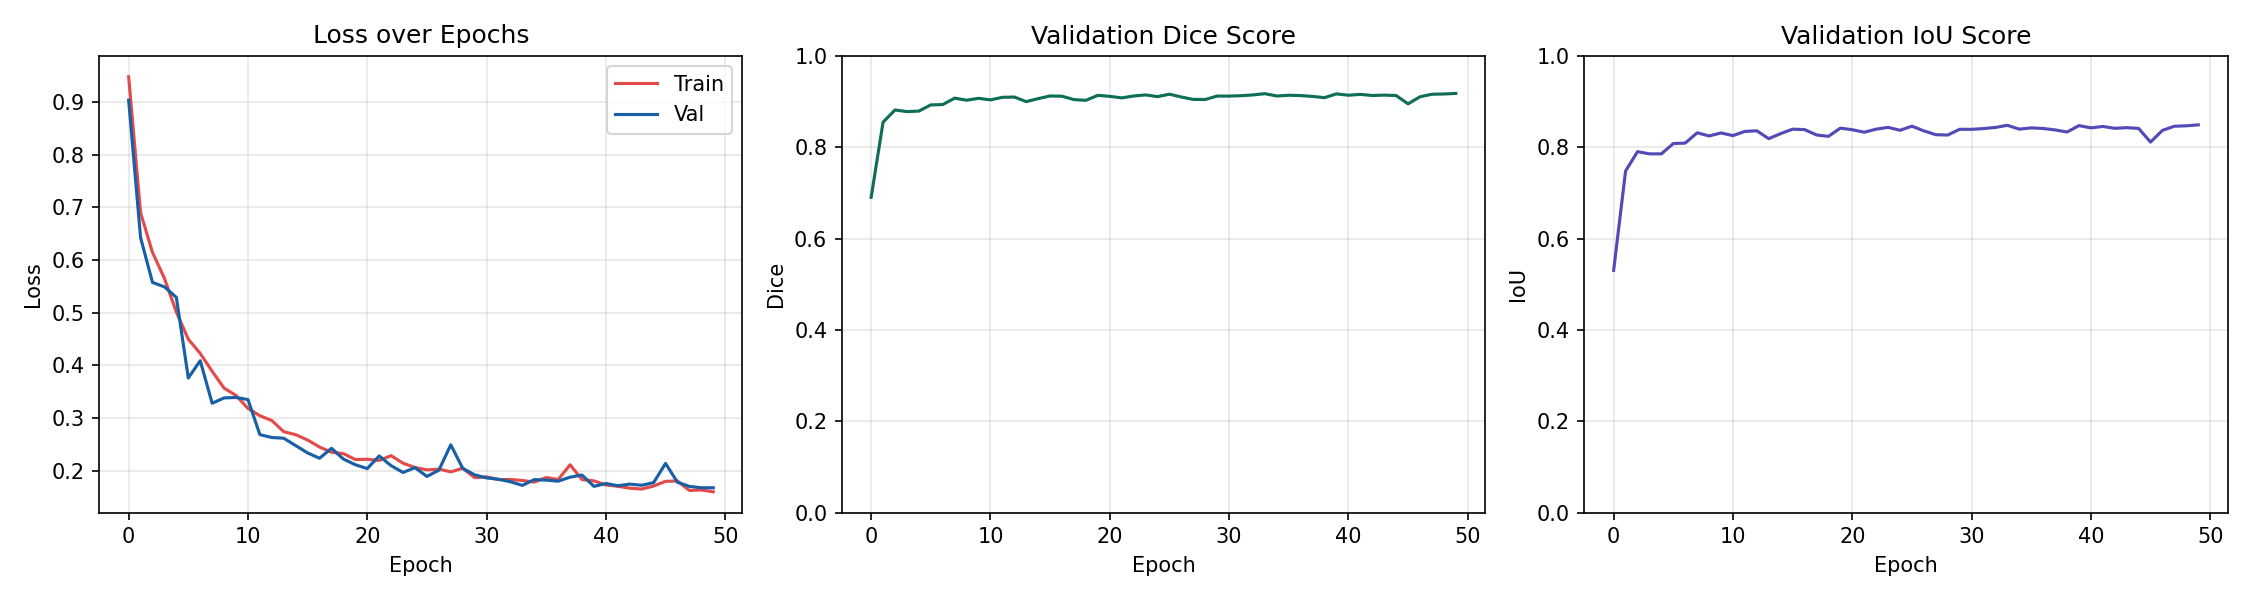

In [8]:
# Display training curves inline
from IPython.display import Image, display
display(Image('/content/Medical-Image-Segmentation-with-UNet-Variants/reports/figures/training_curves.png'))

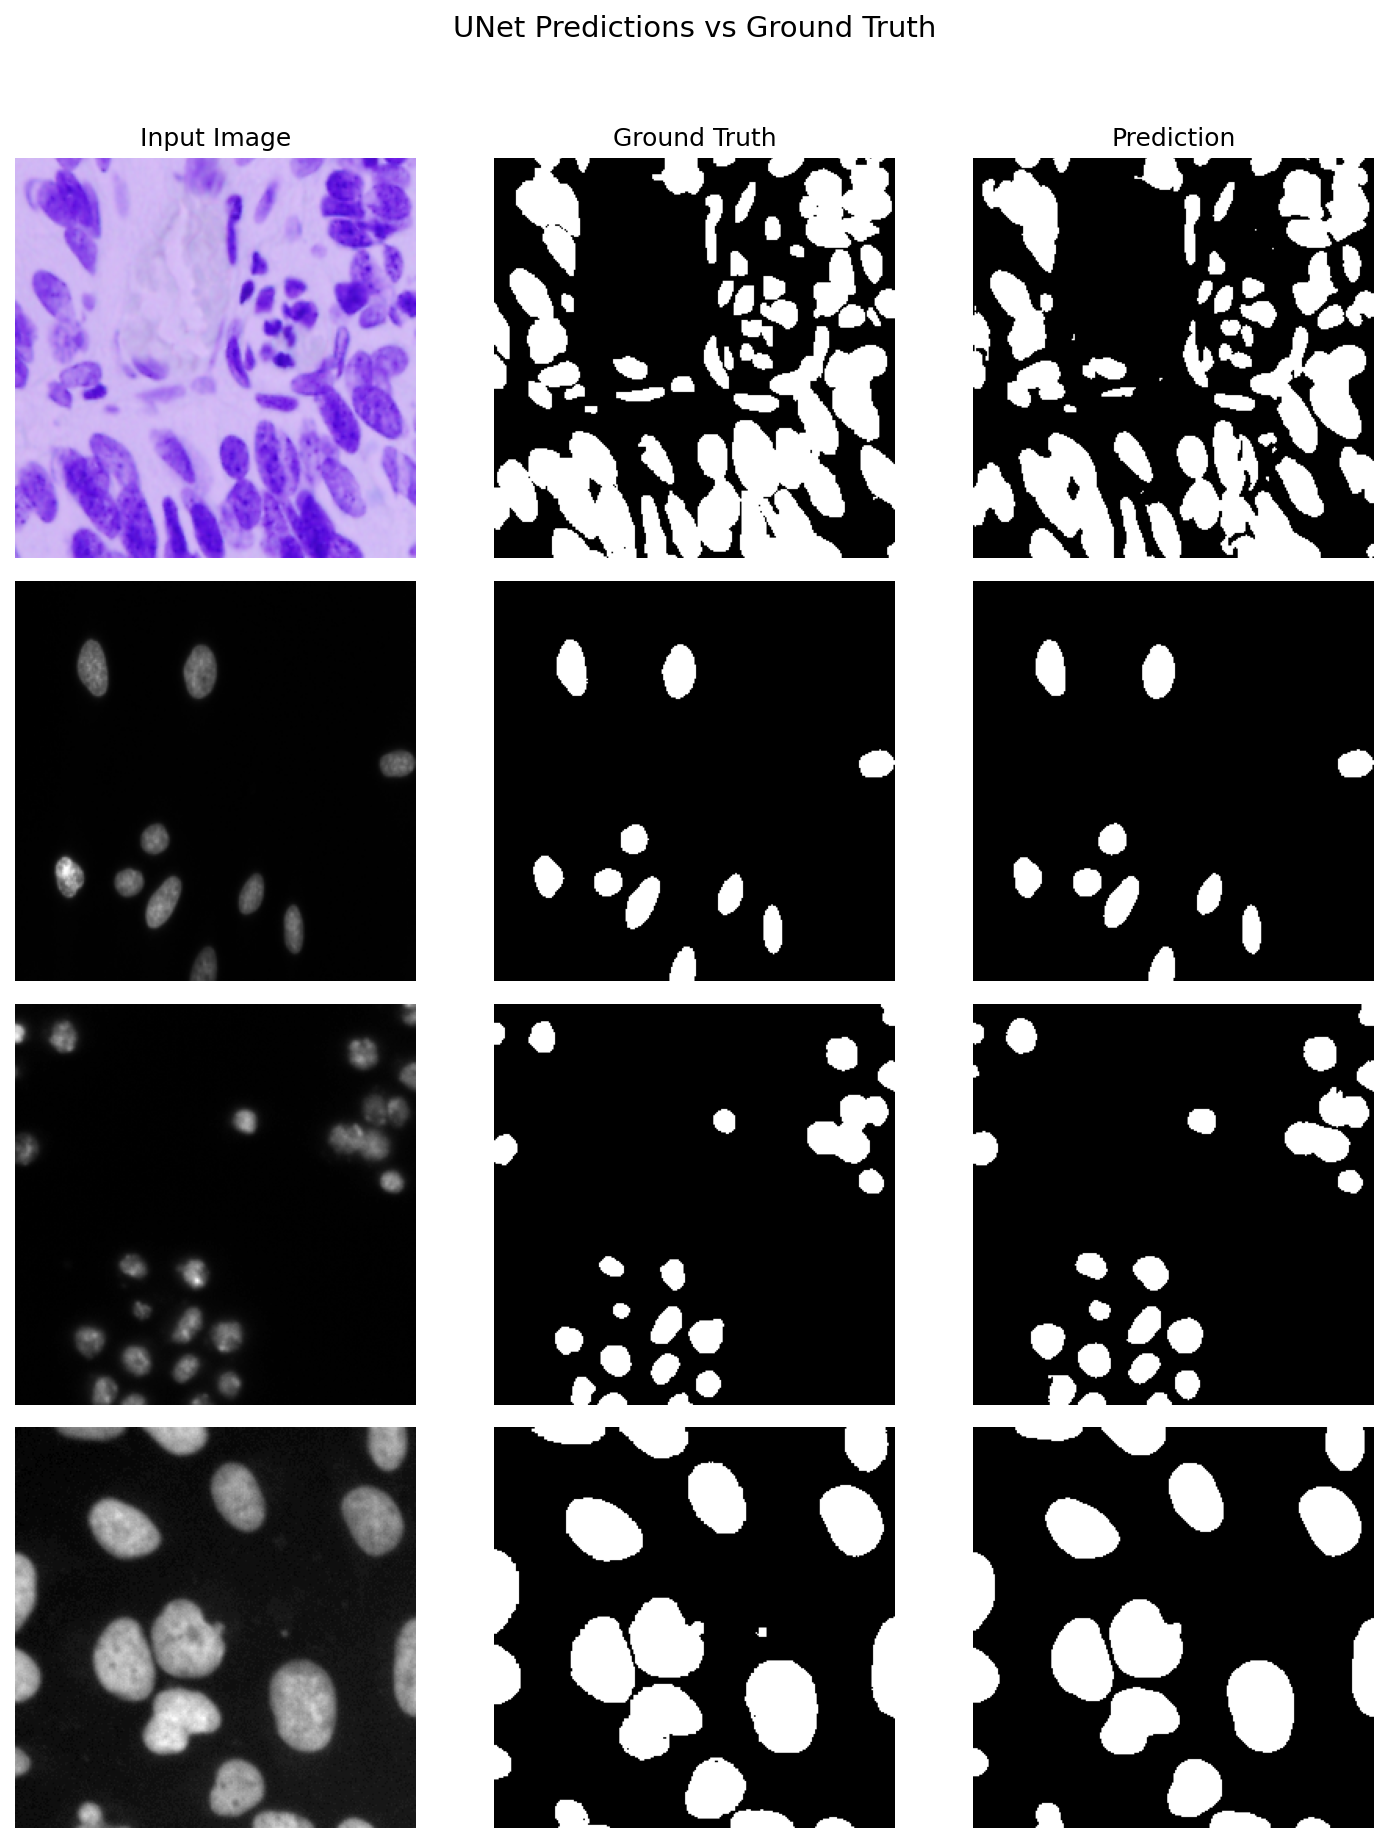

In [10]:
# Display prediction grid inline
display(Image('/content/Medical-Image-Segmentation-with-UNet-Variants/reports/figures/predictions.png'))

In [11]:
# Print final metrics
with open('/content/Medical-Image-Segmentation-with-UNet-Variants/reports/figures/metrics.txt') as f:
    print(f.read())

Final Evaluation Results
Model    : UNet
Dataset  : 2018 Data Science Bowl

val_dice            : 0.9180
val_iou             : 0.8492
val_loss            : 0.1679

